# 05 — Model Comparison
## Paddy Yield Predictor

Compare baseline regression models using the same train/test split and preprocessing.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
PROJECT_ROOT=Path.cwd().parent
df=pd.read_csv(PROJECT_ROOT/'paddydataset.csv'); 
df.columns=df.columns.astype(str).str.strip()
TARGET='Paddy yield(in Kg)';
df=df.drop_duplicates().reset_index(drop=True);
X=df.drop(columns=[TARGET]);
y=df[TARGET]

In [2]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.20,random_state=42)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor,ExtraTreesRegressor
num_cols=X.select_dtypes(include=np.number).columns.tolist(); cat_cols=X.select_dtypes(exclude=np.number).columns.tolist()
def make_preprocessor():
    return ColumnTransformer([('num',Pipeline([('imputer',SimpleImputer(strategy='median')),('scaler',StandardScaler())]),num_cols),('cat',Pipeline([('imputer',SimpleImputer(strategy='most_frequent')),('onehot',OneHotEncoder(handle_unknown='ignore'))]),cat_cols)])

In [3]:
models={'Linear Regression':LinearRegression(),'Random Forest':RandomForestRegressor(n_estimators=300,random_state=42,n_jobs=-1),'Gradient Boosting':GradientBoostingRegressor(random_state=42),'Extra Trees':ExtraTreesRegressor(n_estimators=300,random_state=42,n_jobs=-1)}
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
rows=[]
for name,est in models.items():
    pipe=Pipeline([('preprocessor',make_preprocessor()),('model',est)]); pipe.fit(X_train,y_train); p=pipe.predict(X_test)
    rows.append([name,mean_absolute_error(y_test,p),np.sqrt(mean_squared_error(y_test,p)),r2_score(y_test,p)])
comparison=pd.DataFrame(rows,columns=['Model','MAE','RMSE','R2 Score']).sort_values('R2 Score',ascending=False)
display(comparison)
comparison.to_csv(PROJECT_ROOT/'report'/'model_metrics.csv',index=False)

,Model,MAE,RMSE,R2 Score
2,Gradient Boosting,658.256808,908.934673,0.990350
1,Random Forest,693.210432,965.591167,0.989109
3,Extra Trees,702.681545,979.785374,0.988787
0,Linear Regression,768.366333,1019.890367,0.987850


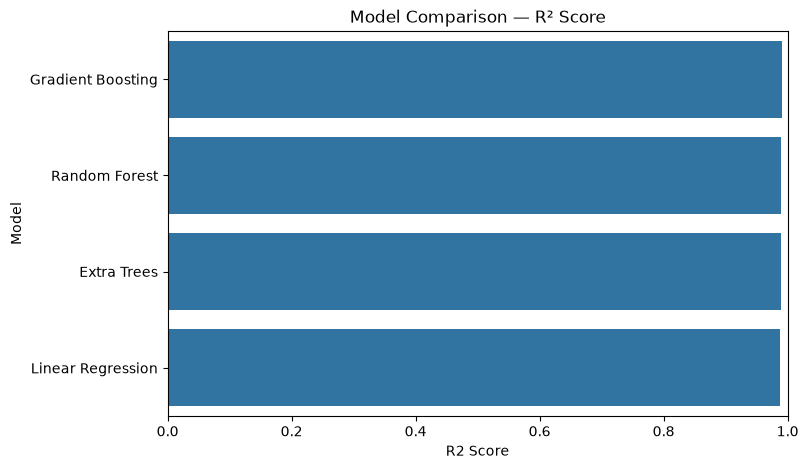

In [4]:
plt.figure(figsize=(8,5)); 
sns.barplot(data=comparison,x='R2 Score',y='Model'); 
plt.title('Model Comparison — R² Score'); 
plt.xlim(0,1); plt.show()

**Decision rule:** lower MAE/RMSE and higher R² are better. The selected model is then tuned in Step 06.